# **Sleep Health Prediction** | 2025

# **I. Data Understanding**

# ***A. Penjabaran Studi Kasus***

Sebuah klinik kesehatan tidur "SleepWell Clinic" ingin mengembangkan sistem deteksi dini gangguan tidur pada pasien mereka. Dengan meningkatnya kasus gangguan tidur di era digital, klinik membutuhkan model machine learning yang dapat memprediksi apakah seseorang memiliki risiko gangguan tidur berdasarkan gaya hidup dan kondisi kesehatannya.

yang harus dilakukan :
- pisahin kolom blood pressure jadi **Systolic_BP** dan **Diastolic_BP**
- buat fitur baru ges :
1. Pulse_Pressure = Systolic - Diastolic
2. Sleep_Quality_Ratio = Quality_of_Sleep / Sleep_Duration
3. Activity_Steps_Ratio = Physical_Activity_Level / (Daily_Steps/100)
4. Age_Group = kelompokin usia **Young Adult**, **Middle Age**, **Senior**

# ***B. Import Libraries***

In [168]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tkinter as tk

# ***C. Import Dataset***

In [169]:
dataset = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")
dataset

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


# **II. Data Preparation**

# ***A. Exploratory Data Analysis***

### 1. Inspeksi Daftar Variabel

In [170]:
dataset.columns

Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps',
       'Sleep Disorder'],
      dtype='object')

### 2. Inspeksi Informasi Ringkas

In [171]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


### 3. Inspeksi Statistik Deskriptif

In [172]:
dataset.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


### 4. Inspeksi Data NaN

In [173]:
dataset.isna().sum()

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

In [174]:
dataset['Sleep Disorder'] = dataset['Sleep Disorder'].fillna("None")

### 5. Inspeksi Data Duplicated

In [175]:
dataset.duplicated().sum()

np.int64(0)

### 6. Encoding

In [176]:
dataset['Occupation'].unique()

array(['Software Engineer', 'Doctor', 'Sales Representative', 'Teacher',
       'Nurse', 'Engineer', 'Accountant', 'Scientist', 'Lawyer',
       'Salesperson', 'Manager'], dtype=object)

In [177]:
dataset['BMI Category'].unique()

array(['Overweight', 'Normal', 'Obese', 'Normal Weight'], dtype=object)

In [178]:
dataset['Sleep Disorder'].unique()

array(['None', 'Sleep Apnea', 'Insomnia'], dtype=object)

In [179]:
dataset = dataset.drop_duplicates()
map_occu = {"Software Engineer" : 0, "Doctor" : 1, "Sales Representative" : 2, "Teacher" : 3, "Nurse" : 4, "Engineer" : 5, "Accountant" : 6, "Scientist" : 7, "Lawyer" : 8, "Salesperson" : 9, "Manager" : 10}
map_bmi = {"Obese" : 0, "Normal" : 1, "Normal Weight" : 2, "Overweight" : 3}
map_gender = {"Male" : 0, "Female" : 1}
map_target = {"None" : 0, "Sleep Apnea" : 1, "Insomnia" : 2}

dataset['Occupation'] = dataset['Occupation'].map(map_occu)
dataset['BMI Category'] = dataset['BMI Category'].map(map_bmi)
dataset['Gender'] = dataset['Gender'].map(map_gender)
dataset['Sleep Disorder'] = dataset['Sleep Disorder'].map(map_target)

### 7. Feature Engineering

#### *a. Sleep_Quality_Ratio*

In [180]:
dataset['Sleep Quality Ratio'] = dataset['Quality of Sleep'] / dataset['Sleep Duration']
dataset['Sleep Quality Ratio']

0      0.983607
1      0.967742
2      0.967742
3      0.677966
4      0.677966
         ...   
369    1.111111
370    1.125000
371    1.111111
372    1.111111
373    1.111111
Name: Sleep Quality Ratio, Length: 374, dtype: float64

#### *b. Activity_Steps_Ratio*

In [181]:
dataset['Activity Steps Ratio'] = dataset['Physical Activity Level'] / (dataset['Daily Steps'] / 100)
dataset['Activity Steps Ratio']

0      1.000000
1      0.600000
2      0.600000
3      1.000000
4      1.000000
         ...   
369    1.071429
370    1.071429
371    1.071429
372    1.071429
373    1.071429
Name: Activity Steps Ratio, Length: 374, dtype: float64

#### *c. Age_Group*

In [182]:
def categorize_age(age):
    if age < 35:
        return 'Young Adult'
    elif age < 60:
        return 'Middle Age'
    else:
        return 'Senior'
    
dataset['Age Group'] = dataset['Age'].apply(categorize_age)
dataset['Age Group']

0      Young Adult
1      Young Adult
2      Young Adult
3      Young Adult
4      Young Adult
          ...     
369     Middle Age
370     Middle Age
371     Middle Age
372     Middle Age
373     Middle Age
Name: Age Group, Length: 374, dtype: object

In [183]:
dataset['Age Group Encoded'] = dataset['Age Group'].replace({
    'Young Adult': 0, 
    'Middle Age': 1, 
    'Senior': 2
})

dataset['Age Group Encoded']

C:\Users\USER\AppData\Local\Temp\ipykernel_3336\1409788843.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataset['Age Group Encoded'] = dataset['Age Group'].replace({


0      0
1      0
2      0
3      0
4      0
      ..
369    1
370    1
371    1
372    1
373    1
Name: Age Group Encoded, Length: 374, dtype: int64

#### *d. Pisahin Blood Pressure jadi **Systolic BP** dan **Diastolic BP***

In [184]:
dataset[['Systolic BP', 'Diastolic BP']] = dataset['Blood Pressure'].str.split('/', expand=True)

dataset['Systolic BP'] = pd.to_numeric(dataset['Systolic BP'])
dataset['Diastolic BP'] = pd.to_numeric(dataset['Diastolic BP'])

dataset = dataset.drop('Blood Pressure', axis=1)

#### *e. Pulse Pressure*

In [185]:
dataset['Pulse Pressure'] = dataset['Systolic BP'] - dataset['Diastolic BP']
dataset['Pulse Pressure']

0      43
1      45
2      45
3      50
4      50
       ..
369    45
370    45
371    45
372    45
373    45
Name: Pulse Pressure, Length: 374, dtype: int64

In [186]:
all_feature = ['Gender', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Systolic BP', 'Diastolic BP', 'Heart Rate', 'Daily Steps', 'Pulse Pressure', 'Sleep Quality Ratio', 'Activity Steps Ratio', 'Age Group']

### 7. Univariate Analysis

#### *a. Inspeksi Distribusi Kelas Target*

In [187]:
target_counts = dataset['Sleep Disorder'].value_counts()
target_counts

Sleep Disorder
0    219
1     78
2     77
Name: count, dtype: int64

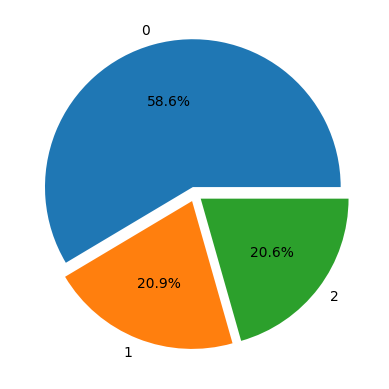

<Figure size 1000x1000 with 0 Axes>

In [188]:
explode = [0.05] * len(target_counts)
plt.pie(target_counts, labels=target_counts.index, explode=explode, autopct="%1.1f%%")
plt.figure(figsize=(10,10))
plt.show()

#### *b. Inspeksi Distribusi Kelas Fitur*

In [189]:
def check_value(cols, top_n=1):
    for col in cols:
        print(dataset[col].value_counts().head(top_n))
        print("\n")

check_value(all_feature, top_n=1)

Gender
0    189
Name: count, dtype: int64


Occupation
4    73
Name: count, dtype: int64


Sleep Duration
7.2    36
Name: count, dtype: int64


Quality of Sleep
8    109
Name: count, dtype: int64


Physical Activity Level
60    70
Name: count, dtype: int64


Stress Level
3    71
Name: count, dtype: int64


BMI Category
1    195
Name: count, dtype: int64


Systolic BP
130    101
Name: count, dtype: int64


Diastolic BP
80    111
Name: count, dtype: int64


Heart Rate
68    94
Name: count, dtype: int64


Daily Steps
8000    101
Name: count, dtype: int64


Pulse Pressure
45    263
Name: count, dtype: int64


Sleep Quality Ratio
1.111111    51
Name: count, dtype: int64


Activity Steps Ratio
0.75    91
Name: count, dtype: int64


Age Group
Middle Age    292
Name: count, dtype: int64




### 8. Bivariate Analysis

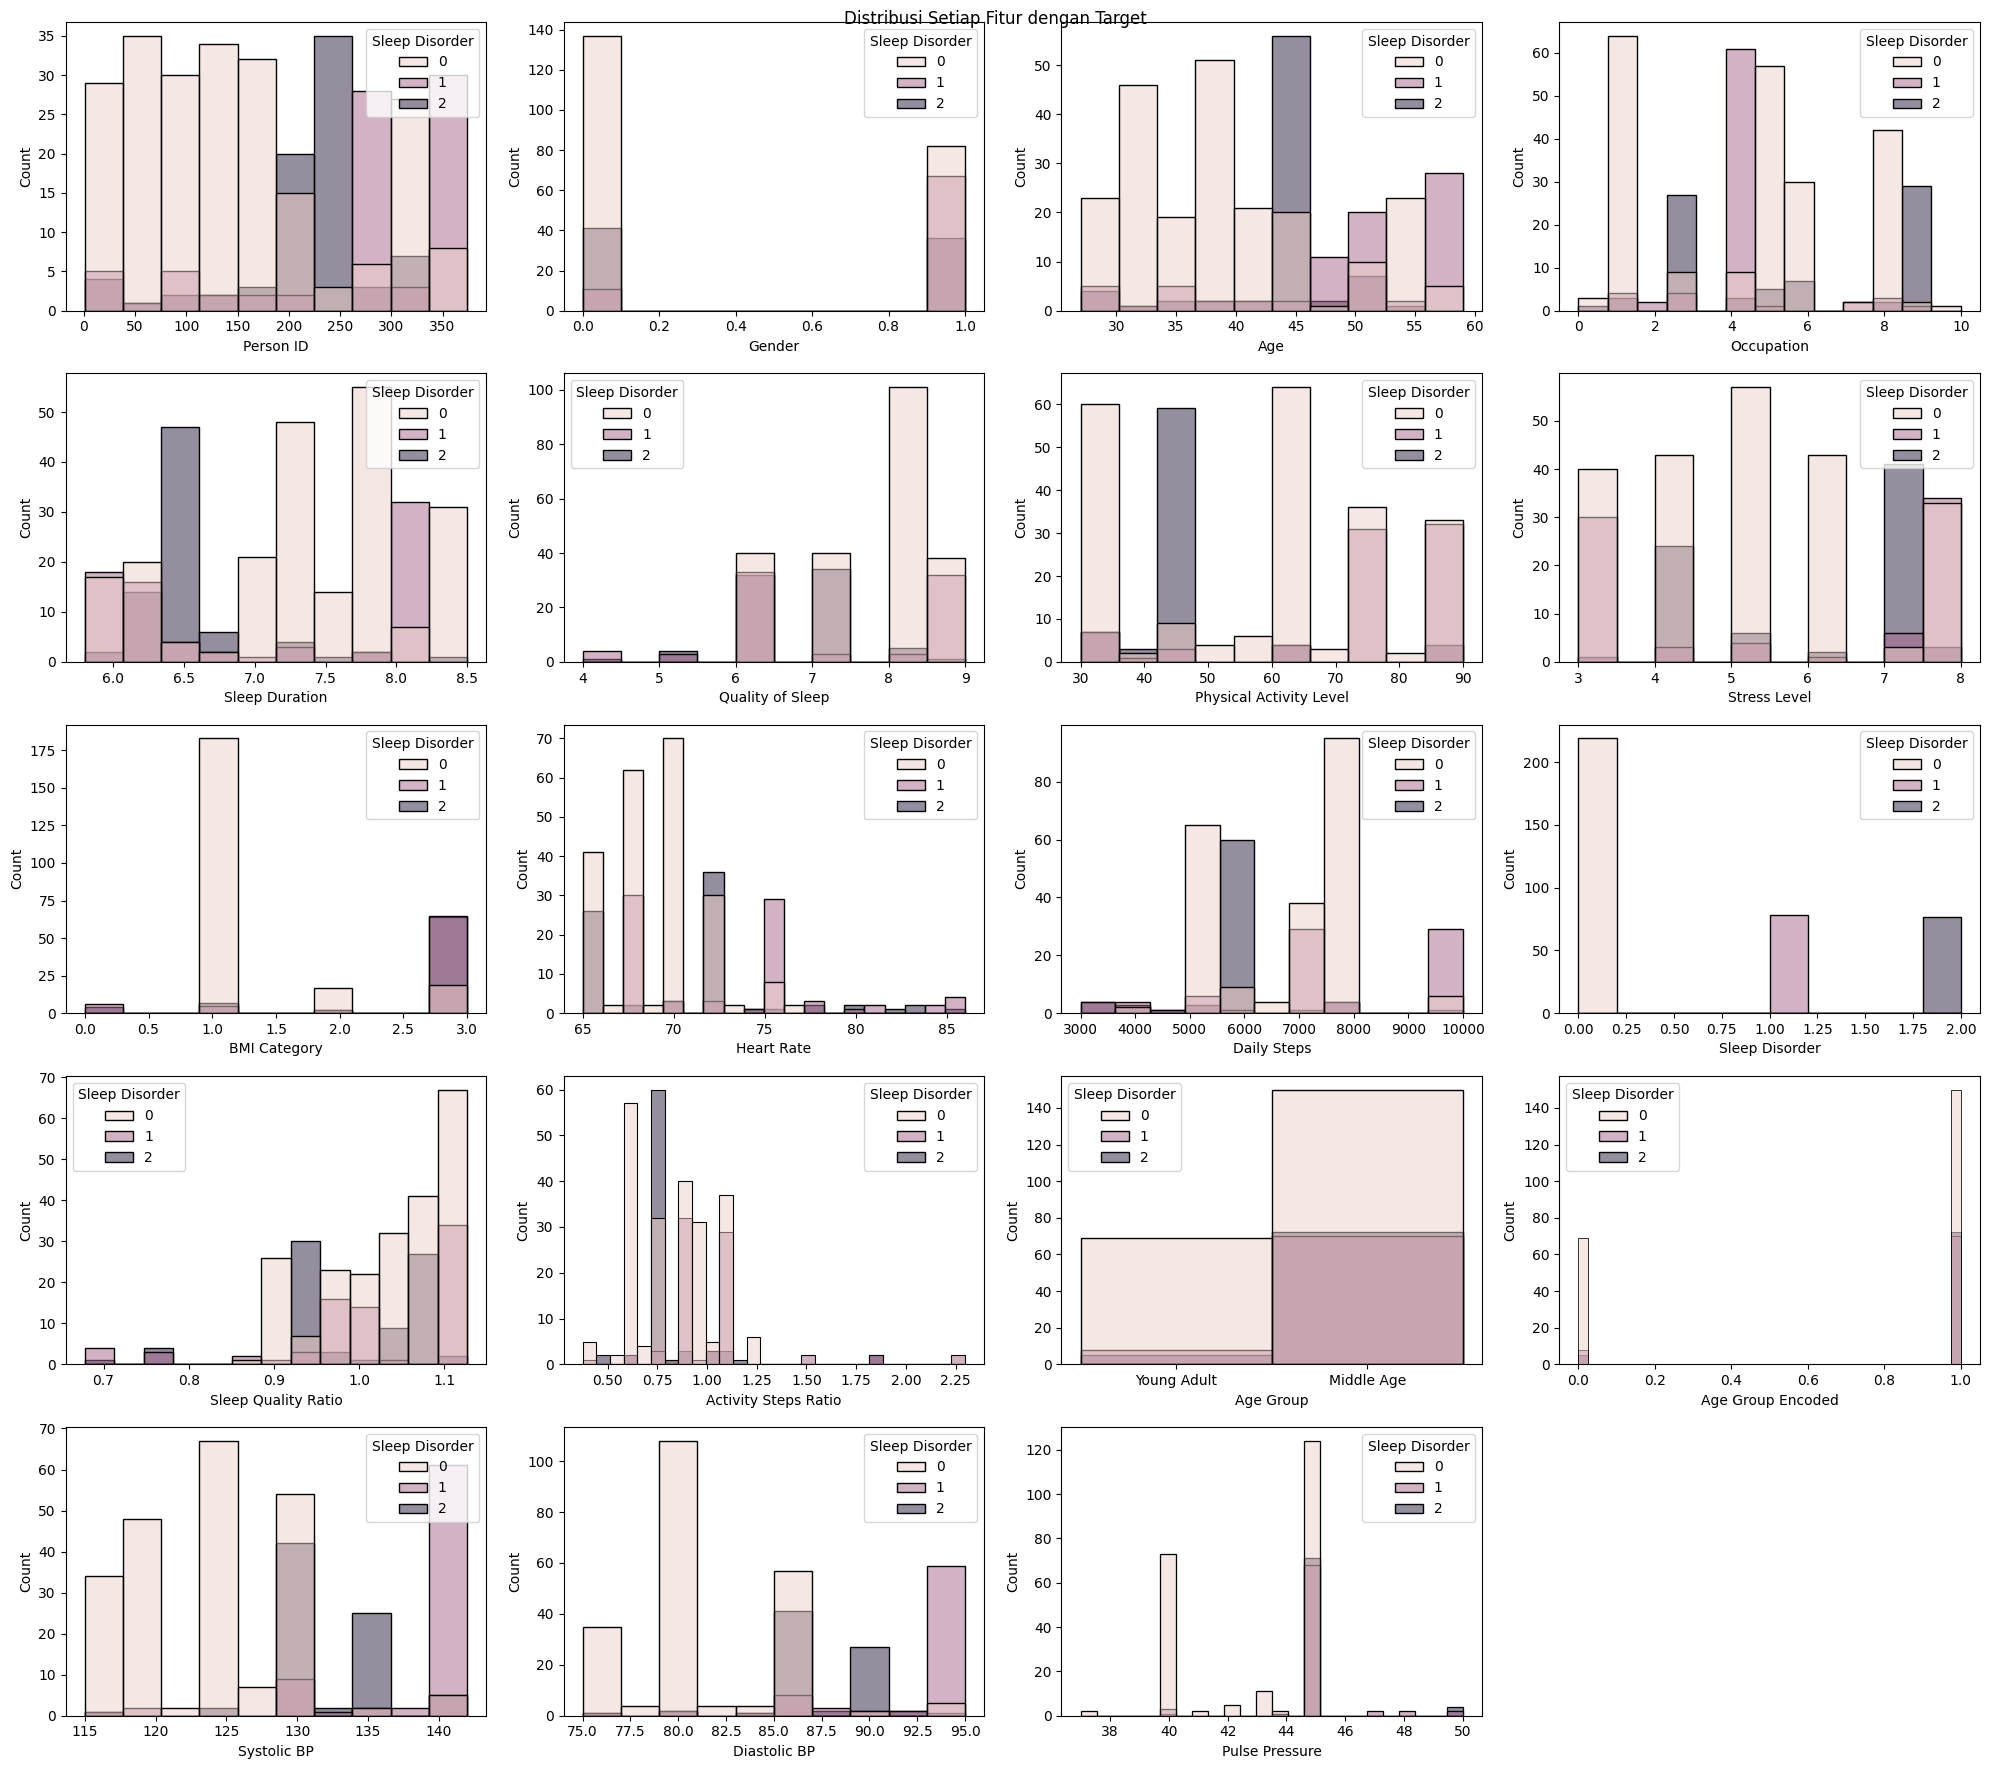

In [190]:
plt.figure(figsize=(20,18))
for i, col in enumerate(dataset):
    plt.subplot(5, 4, i+1)
    sns.histplot(x=dataset[col], hue=dataset["Sleep Disorder"])
plt.suptitle("Distribusi Setiap Fitur dengan Target")
plt.tight_layout()
plt.show()

### 9. Multivariate Analysis

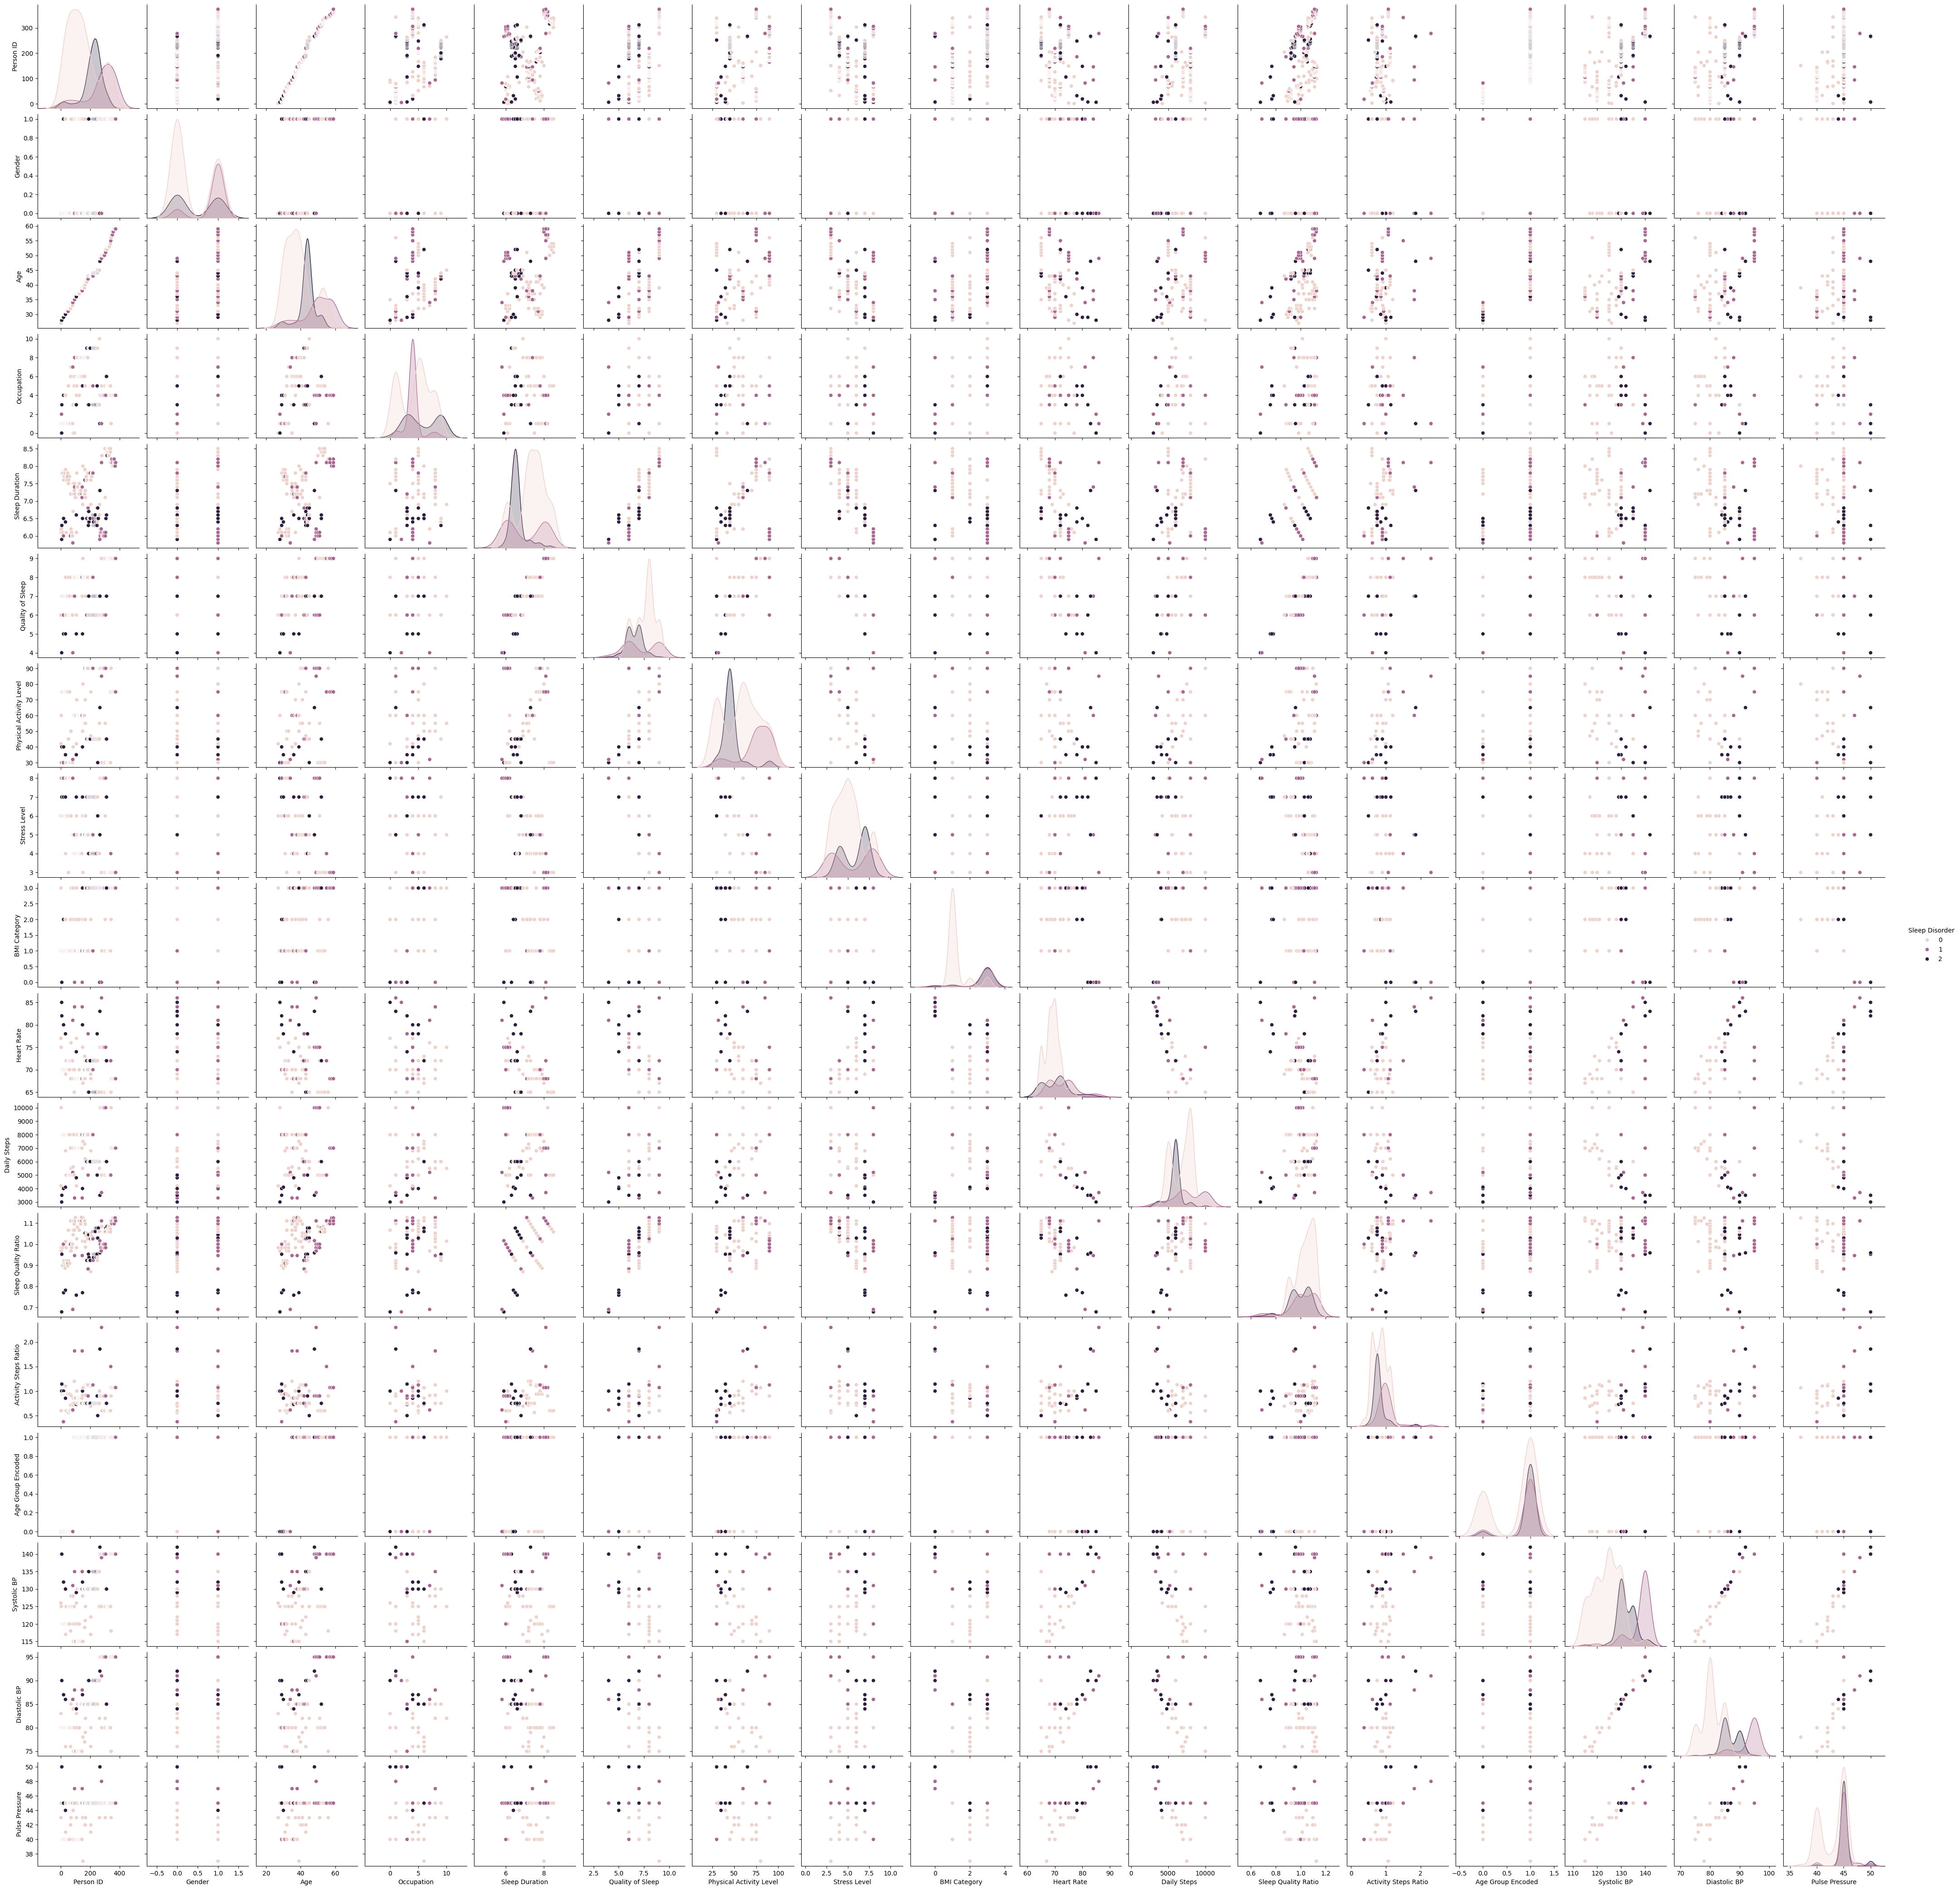

In [191]:
sns.pairplot(dataset, hue="Sleep Disorder")

### 10. Inspeksi Korelasi

#### *a. Mutual Information*

In [192]:
def probability_distribution(x):
    unique, counts = np.unique(x, return_counts=True)
    return counts / counts.sum()

def calculate_entropy(x):
    probs = probability_distribution(x)
    return -np.sum(probs * np.log2(probs + 1e-10))

def mutual_information(x, y):
    xy_pairs = list(zip(x, y))
    unique_xy, counts_xy = np.unique(xy_pairs, return_counts=True)
    probs_xy = counts_xy / counts_xy.sum()
    entropy_xy = -np.sum(probs_xy * np.log2(probs_xy + 1e-10))

    entropy_x = calculate_entropy(x)
    entropy_y = calculate_entropy(y)
    return entropy_x - entropy_y + entropy_xy

fitur = dataset[all_feature]
target = dataset['Sleep Disorder']

mi_scores = {col: mutual_information(fitur[col].values, target.values) for col in fitur.columns}
mi_df = pd.DataFrame(list(mi_scores.items()), columns=["Feature", "Mutual Information"])
mi_df = mi_df.sort_values(by="Mutual Information", ascending=False)
mi_df

,Feature,Mutual Information
12,Sleep Quality Ratio,7.282747
2,Sleep Duration,6.968920
13,Activity Steps Ratio,5.521765
7,Systolic BP,4.654904
10,Daily Steps,4.579192
4,Physical Activity Level,4.574644
9,Heart Rate,4.516282
1,Occupation,4.406640
8,Diastolic BP,4.307091
5,Stress Level,4.150067


C:\Users\USER\AppData\Local\Temp\ipykernel_3336\4128178644.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mi_df, x="Mutual Information", y="Feature", palette="magma")
C:\Users\USER\AppData\Local\Temp\ipykernel_3336\4128178644.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


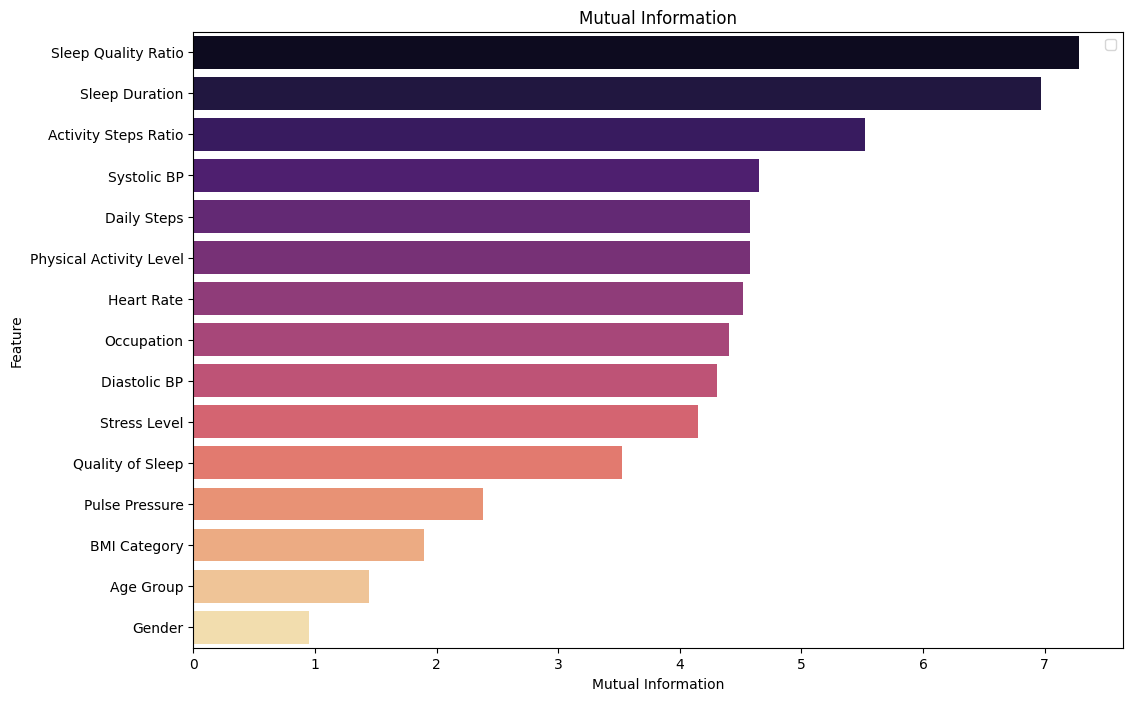

In [193]:
plt.figure(figsize=(12, 8))
sns.barplot(data=mi_df, x="Mutual Information", y="Feature", palette="magma")
plt.xlabel("Mutual Information")
plt.ylabel("Feature")
plt.title("Mutual Information")
plt.legend()
plt.show()

#### *b. Method Kendall*

In [194]:
def kendall_method(x, y):
    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)
    
    concordant = 0
    discordant = 0
    n = len(x)

    for i in range(n - 1):
        for j in range(i+1, n):
            x_diff = x[i] - x[j]  
            y_diff = y[i] - y[j]   

            if x_diff * y_diff > 0:
                concordant += 1
            elif x_diff * y_diff < 0:
                discordant += 1

    total_pairs = concordant + discordant
    if total_pairs == 0:
        return 0.0

    return (concordant - discordant) / total_pairs

In [195]:
numerical_features = [
    'Sleep Duration',
    'Quality of Sleep',
    'Physical Activity Level',
    'Stress Level',
    'Systolic BP',
    'Diastolic BP',
    'Heart Rate',
    'Daily Steps',
    'Pulse Pressure',
    'Sleep Quality Ratio',
    'Activity Steps Ratio'
]

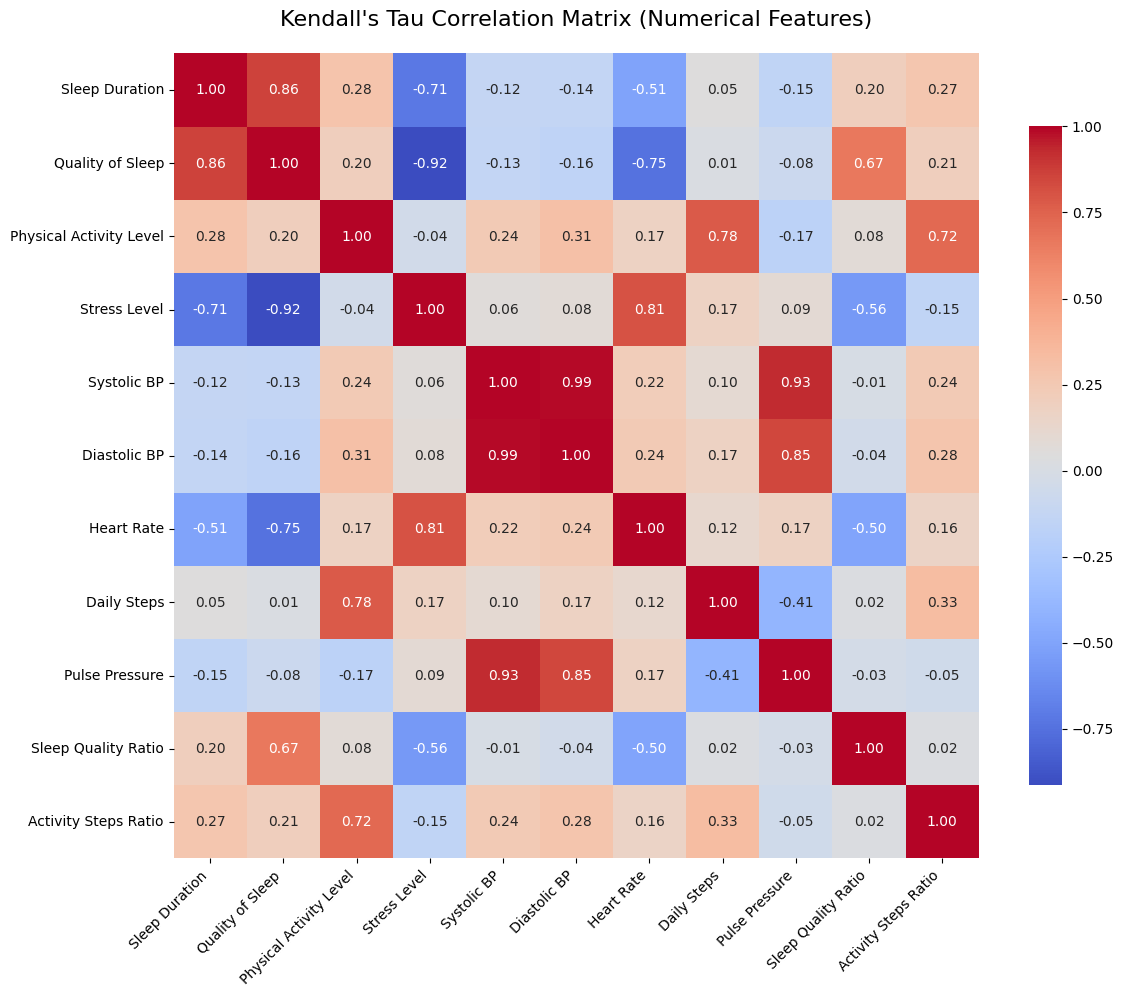

In [196]:
all_kendall = pd.DataFrame(index=numerical_features, columns=numerical_features)

for col1 in numerical_features:
    for col2 in numerical_features:
        all_kendall.loc[col1, col2] = kendall_method(dataset[col1].values, dataset[col2].values)

all_kendall = all_kendall.astype(float)

# Visualisasi
plt.figure(figsize=(12, 10))
sns.heatmap(all_kendall, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={'shrink': .8})
plt.title("Kendall's Tau Correlation Matrix (Numerical Features)", fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#### *c. Method Chi Square*

In [197]:
cat_cols = ['Gender', 'Occupation', 'BMI Category', 'Age Group']

In [198]:
def chi_square(data, col1, col2):
    observed = pd.crosstab(data[col1], data[col2])
    totals = observed.values.sum()
    row_totals = observed.sum(axis=1).values.reshape(-1, 1)
    col_totals = observed.sum(axis=0).values.reshape(1, -1)

    expected = row_totals @ col_totals / totals
    chi_square = ((observed.values - expected) ** 2 / expected).sum()

    return chi_square

chi_scores = []

for col in cat_cols:
    chi = chi_square(dataset, col, "Sleep Disorder")
    chi_scores.append((col, chi))

chi_df = pd.DataFrame(chi_scores, columns=["Feature", "Chi Scores"])
chi_df = chi_df.sort_values(by="Chi Scores", ascending=False)

C:\Users\USER\AppData\Local\Temp\ipykernel_3336\528835947.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=chi_df, x="Feature", y="Chi Scores", palette="viridis")


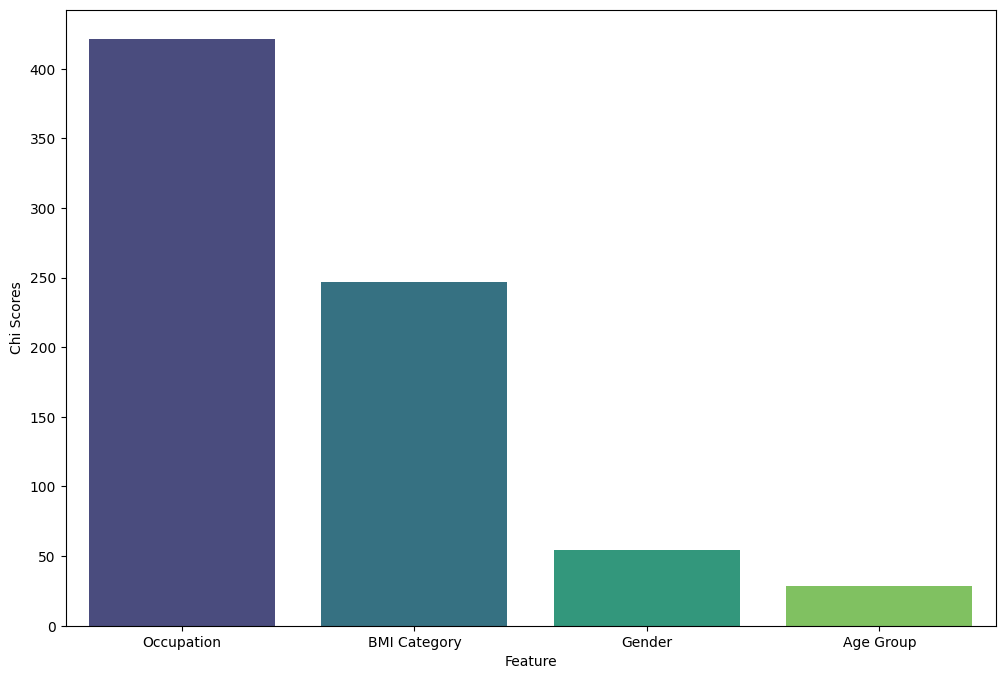

In [199]:
plt.figure(figsize=(12, 8))
sns.barplot(data=chi_df, x="Feature", y="Chi Scores", palette="viridis")
plt.show()

### 11. Inspeksi Outlier

<Axes: xlabel='Sleep Disorder', ylabel='Sleep Quality Ratio'>

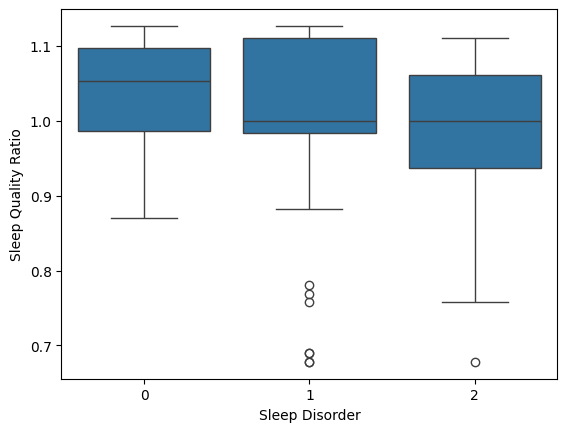

In [200]:
sns.boxplot(data=dataset, x="Sleep Disorder", y="Sleep Quality Ratio")

# ***B. Feature Selection***

In [201]:
feature_cols = ['Sleep Quality Ratio', 'Sleep Duration', 'Activity Steps Ratio', 'Systolic BP', 'Daily Steps', 'Physical Activity Level', 'Heart Rate', 'Occupation', 'Diastolic BP', 'Stress Level']

# ***C. Data Preprocessing***

### 1. Data Imbalance

In [202]:
dataset['Sleep Disorder'].value_counts(normalize=True)*100

Sleep Disorder
0    58.556150
1    20.855615
2    20.588235
Name: proportion, dtype: float64

### 2. Scaling Dataset

In [203]:
means = dataset[numerical_features].mean().values
stds = dataset[numerical_features].std().values
stds = np.where(stds == 0, 1, stds)

dataset_scaled = dataset.copy()
dataset_scaled [numerical_features] = (dataset[numerical_features].values - means) / stds
dataset = dataset_scaled
dataset[numerical_features].describe()

,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Systolic BP,Diastolic BP,Heart Rate,Daily Steps,Pulse Pressure,Sleep Quality Ratio,Activity Steps Ratio
count,3.740000e+02,3.740000e+02,3.740000e+02,3.740000e+02,3.740000e+02,3.740000e+02,3.740000e+02,3.740000e+02,3.740000e+02,3.740000e+02,3.740000e+02
mean,1.405887e-15,2.279816e-16,-4.749617e-17,2.279816e-16,-1.063914e-15,-1.063914e-15,-1.329893e-15,-7.599388e-17,-1.063914e-15,-2.061334e-15,3.847190e-16
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-1.674196e+00,-2.767716e+00,-1.400384e+00,-1.344036e+00,-1.749260e+00,-1.566105e+00,-1.249077e+00,-2.359112e+00,-3.055235e+00,-3.904466e+00,-2.049703e+00
25%,-9.201023e-01,-1.096811e+00,-6.802965e-01,-7.805050e-01,-4.586244e-01,-7.546293e-01,-5.236812e-01,-7.521065e-01,-3.999494e-01,-6.100262e-01,-4.772240e-01
50%,8.535646e-02,-2.613582e-01,3.979093e-02,-2.169744e-01,1.866936e-01,5.684672e-02,-4.008424e-02,1.132043e-01,4.851457e-01,1.996585e-01,-2.794420e-02
75%,8.394505e-01,5.740945e-01,7.598784e-01,9.100869e-01,8.320116e-01,8.683227e-01,4.435127e-01,7.312835e-01,4.851457e-01,8.468842e-01,5.710956e-01
max,1.719227e+00,1.409547e+00,1.479966e+00,1.473618e+00,1.735457e+00,1.679799e+00,3.828691e+00,1.967442e+00,2.697884e+00,1.197845e+00,6.011024e+00


# ***D. Splitting Dataset***

In [204]:
def stratified_split(dataset, target_column, training_size=0.8, random_state=42):
    np.random.seed(random_state)
    train_list, test_list = [], []

    for class_value in dataset[target_column].unique():
        class_data = dataset[dataset[target_column] == class_value]
        class_data = class_data.sample(frac=1, random_state=random_state)

        split_idx = int(len(class_data) * training_size)
        train_list.append(class_data.iloc[:split_idx])
        test_list.append(class_data.iloc[split_idx:])

    train_set = pd.concat(train_list).reset_index(drop=True)
    test_set = pd.concat(test_list).reset_index(drop=True)
    return train_set, test_set

dataset_training, dataset_testing = stratified_split(dataset, "Sleep Disorder")

# ***F. Data Sampling***

# ***G. Feature Target Declaration***

In [205]:
X_train = dataset_training[feature_cols].to_numpy()
X_test = dataset_testing[feature_cols].to_numpy()
y_train = dataset_training['Sleep Disorder'].to_numpy()
y_test = dataset_testing['Sleep Disorder'].to_numpy()

# **III. Modeling**

# ***A. Model Application***

In [206]:
class ManualNaiveBay:
    def __init__(self, class_prior=None):
        self.classes = None
        self.priors = {}
        self.mean = {}
        self.var = {}
        self.class_prior = class_prior

    def fit(self, X, y):
        self.classes  = np.unique(y)
        n_samples, n_features = X.shape

        for c in self.classes:
            X_c = X[y == c]
            if self.class_prior is not None:
                self.priors[c] = self.class_prior[c]
            else:
                self.priors[c] = len(X_c) / n_samples
            self.mean[c] = np.mean(X_c, axis=0)
            self.var[c] = np.var(X_c, axis=0) + 1e-9

    def _gaussian(self, x, mean, var):
        coeff = 1 / np.sqrt(2 * np.pi * var)
        exponent = np.exp(- (x - mean)**2 / (2 * var))
        return coeff * exponent

    def predict_proba(self, X):
        n_samples, n_features = X.shape
        probabilities = np.zeros((n_samples, len(self.classes)))

        for idx, c in enumerate(self.classes):
            prior = np.log(self.priors[c])
            likelihood = np.sum(np.log(self._gaussian(X, self.mean[c], self.var[c])), axis=1)
            probabilities[:, idx] = prior + likelihood

        exp_probs = np.exp(probabilities - np.max(probabilities, axis=1, keepdims=True))
        return exp_probs / np.sum(exp_probs, axis=1, keepdims=True)

    def predict(self, X):
        proba = self.predict_proba(X)
        return self.classes[np.argmax(proba, axis=1)]

In [207]:
nb_model = ManualNaiveBay(class_prior={0: 1/3, 1: 1/3, 2: 1/3})
nb_model.fit(X_train, y_train)
y_pred = nb_model.predict(X_test)
y_proba = nb_model.predict_proba(X_test)
y_proba_train = nb_model.predict_proba(X_train)

# ***B. Visualisasi Model***

### 1. Distribusi Hasil Prediksi

In [208]:
y_train_pred = nb_model.predict(X_train)
y_test_pred = nb_model.predict(X_test)

#### *a. Training Model*

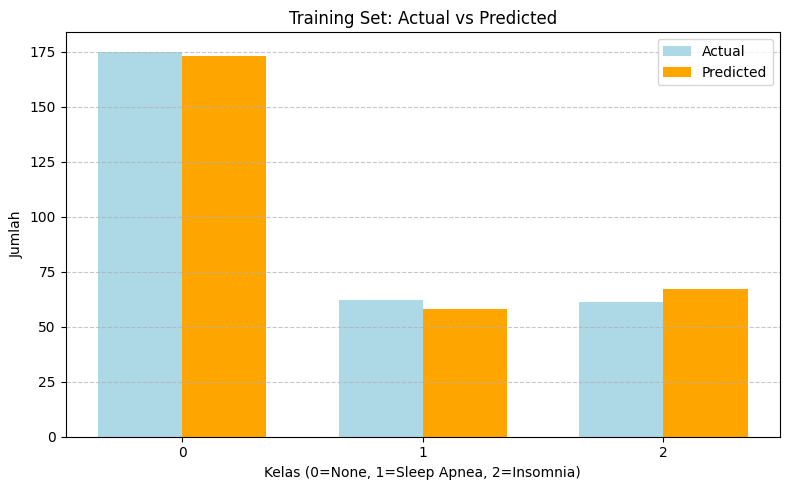

In [209]:
plt.figure(figsize=(8, 5))

# Hitung jumlah actual & predicted
actual_train = pd.Series(y_train).value_counts().sort_index()
predicted_train = pd.Series(y_train_pred).value_counts().sort_index()

# Pastikan index 0,1,2 semua ada (kalau ada kelas yang nggak muncul, isi 0)
for i in [0,1,2]:
    if i not in actual_train.index:
        actual_train[i] = 0
    if i not in predicted_train.index:
        predicted_train[i] = 0

actual_train = actual_train.sort_index()
predicted_train = predicted_train.sort_index()

# Plot bar
bar_width = 0.35
index = np.arange(len(actual_train))

plt.bar(index - bar_width/2, actual_train.values, bar_width, label='Actual', color='lightblue')
plt.bar(index + bar_width/2, predicted_train.values, bar_width, label='Predicted', color='orange')

plt.xlabel('Kelas (0=None, 1=Sleep Apnea, 2=Insomnia)')
plt.ylabel('Jumlah')
plt.title('Training Set: Actual vs Predicted')
plt.xticks(index, ['0', '1', '2'])
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### *b. Testing Model*

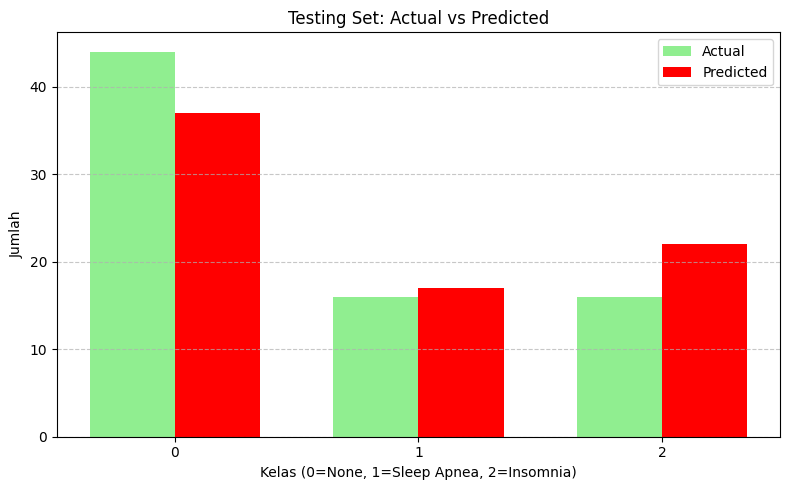

In [210]:
plt.figure(figsize=(8, 5))

actual_test = pd.Series(y_test).value_counts().sort_index()
predicted_test = pd.Series(y_test_pred).value_counts().sort_index()

for i in [0,1,2]:
    if i not in actual_test.index:
        actual_test[i] = 0
    if i not in predicted_test.index:
        predicted_test[i] = 0

actual_test = actual_test.sort_index()
predicted_test = predicted_test.sort_index()

plt.bar(index - bar_width/2, actual_test.values, bar_width, label='Actual', color='lightgreen')
plt.bar(index + bar_width/2, predicted_test.values, bar_width, label='Predicted', color='red')

plt.xlabel('Kelas (0=None, 1=Sleep Apnea, 2=Insomnia)')
plt.ylabel('Jumlah')
plt.title('Testing Set: Actual vs Predicted')
plt.xticks(index, ['0', '1', '2'])
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 2. Confusion Matrix

In [211]:
def confusion_matrix(y_true, y_pred, n_classes=3):
    cm = np.zeros((n_classes, n_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm

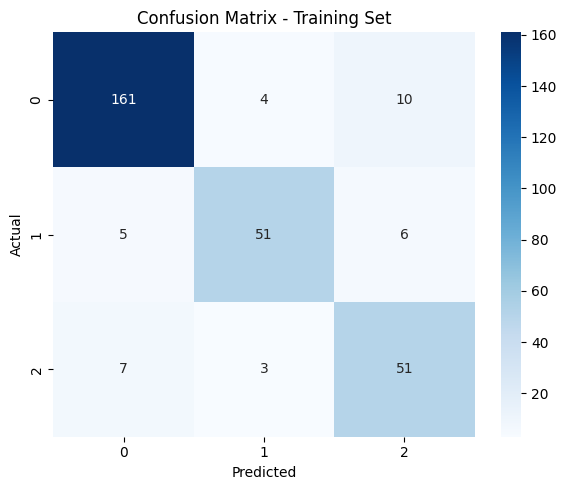

In [212]:
cm_train = confusion_matrix(y_train, y_train_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0, 1, 2], yticklabels=[0, 1, 2])
plt.title('Confusion Matrix - Training Set')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

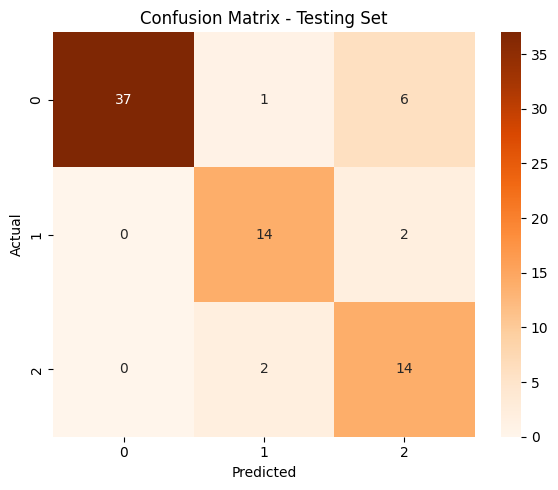

In [213]:
cm_test = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Oranges',
            xticklabels=[0, 1, 2], yticklabels=[0, 1, 2])
plt.title('Confusion Matrix - Testing Set')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# ***C. Evaluasi Model***

### 1. Confusion Matrix

In [214]:
def evaluation_metric(y_true, y_pred, average):
    accuracy_list, precision_list, recall_list, f1_list = [], [], [], []
    labels = np.unique(y_true)

    for label in labels:
        TP = np.sum((y_true == label) & (y_pred == label))
        FP = np.sum((y_true != label) & (y_pred == label))

        TN = np.sum((y_true != label) & (y_pred != label))
        FN = np.sum((y_true == label) & (y_pred != label))

        accuracy = (TP + TN) / (TP + TN + FP + FN) * 100 if  (TP + TN + FP + FN) != 0 else 0
        precision = TP / (TP + FP) if  (TP + FP)  != 0 else 0
        recall = TP / (TP + FN) if (TP + FN) != 0 else 0
        f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

        accuracy_list.append(accuracy)
        precision_list.append(precision)
        recall_list.append(recall)
        f1_list.append(f1_score)

    if average == 'macro':
        accuracy = np.mean(accuracy_list)
        precision = np.mean(precision_list)
        recall = np.mean(recall_list)
        f1_score = np.mean(f1_list)

    elif average == 'micro':
        TP = np.sum(y_true == y_pred)
        FP = np.sum((y_true != y_pred) & (y_pred != y_true))

        TN = np.sum(y_true == y_pred)
        FN = np.sum((y_true == y_pred) & (y_true != y_pred))

        accuracy = (TP + TN) /  (TP + TN + FP + FN) * 100 if  (TP + TN + FP + FN) != 0 else 0
        precision = TP / (TP + FP) if  (TP + FP)  != 0 else 0
        recall = TP / (TP + FN) if (TP + FN) != 0 else 0
        f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

    return accuracy, precision, recall, f1_score

In [215]:
accuracy_train, precision_train, recall_train, f1_train = evaluation_metric(y_train, y_train_pred, average='macro')
print(f"Akurasi Train: {accuracy_train:.2f}")
print(f"Presisi Train: {precision_train:.2f}")
print(f"Recall Train: {recall_train:.2f}")
print(f"F1 Score Train: {f1_train:.2f}")

Akurasi Train: 92.17
Presisi Train: 0.86
Recall Train: 0.86
F1 Score Train: 0.86


In [216]:
accuracy_test, precision_test, recall_test, f1_test = evaluation_metric(y_test, y_test_pred, average='macro')
print(f"Akurasi Test: {accuracy_test:.2f}")
print(f"Presisi Test: {precision_test:.2f}")
print(f"Recall Test: {recall_test:.2f}")
print(f"F1 Score Test: {f1_test:.2f}")

Akurasi Test: 90.35
Presisi Test: 0.82
Recall Test: 0.86
F1 Score Test: 0.83


### 2. Bias and Variance Model

In [217]:
train_true_proba = np.array([y_proba_train[i, y_train[i]] for i in range(len(y_train))])
test_true_proba = np.array([y_proba[i, y_test[i]] for i in range(len(y_test))])

train_error = 1 - train_true_proba
test_error = 1 - test_true_proba

error_df = pd.DataFrame({
    'Error': np.concatenate([train_error, test_error]),
    'Set': ['Training'] * len(train_error) + ['Testing'] * len(test_error)
})

C:\Users\USER\AppData\Local\Temp\ipykernel_3336\2797449554.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=error_df, x='Set', y='Error', palette=['lightblue', 'lightcoral'])


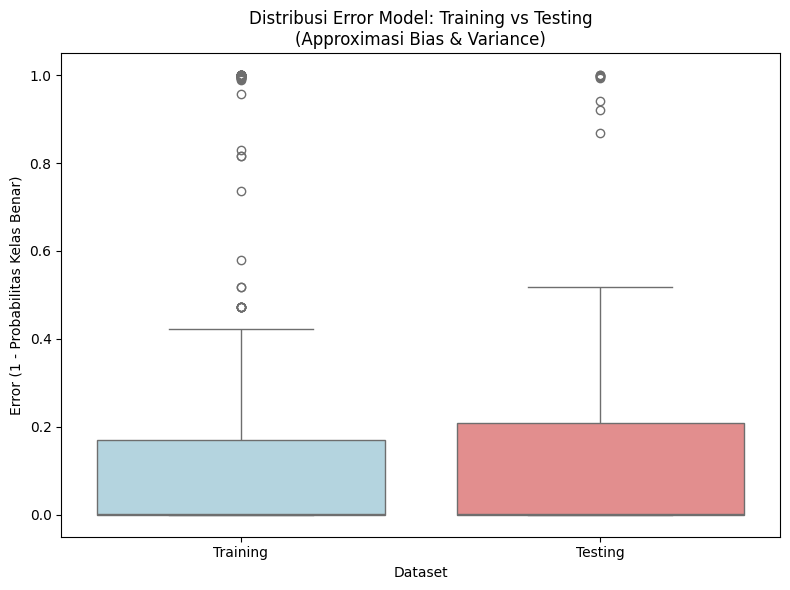

In [218]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=error_df, x='Set', y='Error', palette=['lightblue', 'lightcoral'])
plt.title('Distribusi Error Model: Training vs Testing\n(Approximasi Bias & Variance)')
plt.ylabel('Error (1 - Probabilitas Kelas Benar)')
plt.xlabel('Dataset')
plt.tight_layout()
plt.show()

### 3. K-Fold Cross Validation

In [221]:
def stratified_kfold(y, n_splits=5, random_state=42):
    np.random.seed(random_state)
    classes = np.unique(y)
    fold_indices = [[] for _ in range(n_splits)]
    
    for cls in classes:
        cls_indices = np.where(y == cls)[0]
        np.random.shuffle(cls_indices)
        
        # ✅ FIX: np.array_split, bukan array_splits
        folds = np.array_split(cls_indices, n_splits)
        for i, fold in enumerate(folds):
            fold_indices[i].extend(fold)
    
    # Acak isi tiap fold (opsional)
    for i in range(n_splits):
        np.random.shuffle(fold_indices[i])
    
    return fold_indices

In [222]:
# Siapkan data lengkap (X_all, y_all) — ambil dari dataset asli sebelum split
X_all = dataset[feature_cols].to_numpy()
y_all = dataset['Sleep Disorder'].to_numpy()

# Tentukan jumlah fold
n_splits = 5

# Dapatkan indeks fold
fold_indices = stratified_kfold(y_all, n_splits=n_splits)

# Simpan hasil evaluasi tiap fold
fold_results = []

for fold in range(n_splits):
    # Tentukan test index dan train index
    test_idx = fold_indices[fold]
    train_idx = np.concatenate([fold_indices[i] for i in range(n_splits) if i != fold])
    
    # Split data
    X_train_fold, X_test_fold = X_all[train_idx], X_all[test_idx]
    y_train_fold, y_test_fold = y_all[train_idx], y_all[test_idx]
    
    # Latih model
    nb_cv = ManualNaiveBay(class_prior={0: 1/3, 1: 1/3, 2: 1/3})
    nb_cv.fit(X_train_fold, y_train_fold)
    
    # Prediksi
    y_pred_fold = nb_cv.predict(X_test_fold)
    
    # Evaluasi
    acc, prec, rec, f1 = evaluation_metric(y_test_fold, y_pred_fold, average='macro')
    
    # Simpan
    fold_results.append({
        'Fold': fold + 1,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })

# Jadikan DataFrame
cv_df = pd.DataFrame(fold_results)
print("Hasil K-Fold Cross Validation:")
print(cv_df)
print("\nRata-Rata:")
print(cv_df.mean(numeric_only=True).round(4))

Hasil K-Fold Cross Validation:
   Fold   Accuracy  Precision    Recall  F1-Score
0     1  92.105263   0.838207  0.878788  0.854429
1     2  89.473684   0.808795  0.803030  0.800128
2     3  92.888889   0.861620  0.870328  0.864579
3     4  97.297297   0.978723  0.933333  0.951974
4     5  89.041096   0.824359  0.834625  0.822490

Rata-Rata:
Fold          3.0000
Accuracy     92.1612
Precision     0.8623
Recall        0.8640
F1-Score      0.8587
dtype: float64


# **IV. GUI**

In [223]:
def predict_from_gui():
    try:
        # Ambil nilai dari input fields
        inputs = []
        for entry in entries:
            val = float(entry.get())
            inputs.append(val)
        
        # Konversi ke array numpy
        X_input = np.array(inputs).reshape(1, -1)
        
        # Prediksi
        pred_class = nb_model.predict(X_input)[0]
        pred_proba = nb_model.predict_proba(X_input)[0]
        
        # Mapping kelas
        class_names = {0: "None", 1: "Sleep Apnea", 2: "Insomnia"}
        result_text = f"Hasil Prediksi: {class_names[pred_class]}\n\n"
        result_text += "Probabilitas:\n"
        for i, prob in enumerate(pred_proba):
            result_text += f"{class_names[i]}: {prob:.4f}\n"
        
        # Tampilkan
        result_label.config(text=result_text)
        
    except Exception as e:
        tk.messagebox.showerror("Error", f"Input tidak valid!\nPastikan semua kolom diisi dengan angka.\n\nError: {str(e)}")

def reset_inputs():
    for entry in entries:
        entry.delete(0, tk.END)
    result_label.config(text="Hasil prediksi akan muncul di sini...")

def fill_example():
    if len(X_test) > 0:
        example_data = X_test[0]  # ambil sampel pertama dari testing set
        for i, val in enumerate(example_data):
            entries[i].delete(0, tk.END)
            entries[i].insert(0, f"{val:.2f}")
    else:
        tk.messagebox.showinfo("Info", "Dataset testing kosong!")

# --- GUI WINDOW ---
root = tk.Tk()
root.title("🌙 Sleep Health Prediction - SleepWell Clinic")
root.geometry("600x700")
root.configure(bg="#f0f8ff")

# Judul
title_label = tk.Label(root, text="Sistem Deteksi Gangguan Tidur", 
                      font=("Arial", 16, "bold"), bg="#f0f8ff", fg="#2c3e50")
title_label.pack(pady=15)

# Frame Input
input_frame = tk.Frame(root, bg="#f0f8ff")
input_frame.pack(pady=10, padx=20, fill="x")

entries = []
feature_labels = [
    'Sleep Quality Ratio',
    'Sleep Duration',
    'Activity Steps Ratio',
    'Systolic BP',
    'Daily Steps',
    'Physical Activity Level',
    'Heart Rate',
    'Occupation',
    'Diastolic BP',
    'Stress Level'
]

for i, label_text in enumerate(feature_labels):
    row = i // 2
    col = (i % 2) * 2
    
    # Label
    tk.Label(input_frame, text=label_text+":", bg="#f0f8ff", font=("Arial", 10)).grid(row=row, column=col, sticky="w", padx=5, pady=5)
    
    # Entry
    entry = tk.Entry(input_frame, width=12, font=("Arial", 10))
    entry.grid(row=row, column=col+1, padx=5, pady=5)
    entries.append(entry)

# Tombol
button_frame = tk.Frame(root, bg="#f0f8ff")
button_frame.pack(pady=15)

predict_btn = tk.Button(button_frame, text="PREDIKSI", command=predict_from_gui, 
                       bg="#3498db", fg="white", font=("Arial", 11, "bold"), padx=15)
predict_btn.grid(row=0, column=0, padx=10)

example_btn = tk.Button(button_frame, text="ISI CONTOH", command=fill_example,
                       bg="#2ecc71", fg="white", font=("Arial", 11, "bold"), padx=10)
example_btn.grid(row=0, column=1, padx=10)

reset_btn = tk.Button(button_frame, text="RESET", command=reset_inputs,
                     bg="#e74c3c", fg="white", font=("Arial", 11, "bold"), padx=20)
reset_btn.grid(row=0, column=2, padx=10)

# Hasil
result_label = tk.Label(root, text="Hasil prediksi akan muncul di sini...", 
                       bg="#ffffff", fg="#2c3e50", font=("Arial", 12), 
                       relief="sunken", padx=10, pady=10, justify="left")
result_label.pack(pady=20, padx=30, fill="both", expand=True)

# Footer
footer = tk.Label(root, text="© 2025 SleepWell Clinic | Powered by Naive Bayes", 
                 bg="#f0f8ff", fg="#7f8c8d", font=("Arial", 9))
footer.pack(side="bottom", pady=5)

# Jalankan GUI
root.mainloop()

C:\Users\USER\AppData\Local\Temp\ipykernel_3336\1247187064.py:33: RuntimeWarning: divide by zero encountered in log
  likelihood = np.sum(np.log(self._gaussian(X, self.mean[c], self.var[c])), axis=1)
C:\Users\USER\AppData\Local\Temp\ipykernel_3336\1247187064.py:36: RuntimeWarning: invalid value encountered in subtract
  exp_probs = np.exp(probabilities - np.max(probabilities, axis=1, keepdims=True))
